# Experimentação causal: a ação preventiva paga a conta?

> **DADOS SINTÉTICOS, DEMONSTRAÇÃO DE MÉTODO.** O efeito verdadeiro do cupom é *plantado* no gerador (`experimento_causal/dgp.py`). Este notebook mostra que a máquina de análise recupera o que foi plantado e aplica a regra de decisão econômica. Ele **não afirma** que o cupom funciona nem cita ROI medido. Registro de decisão: `docs/adr/0002-arco-de-experimentacao-causal.md` e `docs/spec/0002-experimento-causal.md`.

## A virada

A Fase 1 respondeu *"quem vai virar detrator?"* — modelo preditivo, validado por F1/recall, tradução em ROI **hipotético** (premissas de retenção e LTV que ninguém mediu).

A continuidade responde outra pergunta: *"a ação muda o desfecho, e o quanto que muda paga a conta?"* — isso é inferência **causal**, e só um experimento controlado responde. O modelo preditivo passa a ser o **critério de elegibilidade**; a evidência de valor vem do A/B.

In [1]:
import sys; sys.path.insert(0, '..')
from IPython.display import Image, Markdown
import pandas as pd, json
from experimento_causal import config as cfg
from experimento_causal.calibracao_modelo import diagnosticar, resumo_elegibilidade
from experimento_causal.dgp import CenarioDGP, gerar_populacao, resumo
from experimento_causal.randomizacao import sortear, checar_balanco
from experimento_causal.analise import analisar, validar_recuperacao
from experimento_causal.dimensionamento import tabela_mde, criterio_pre_registrado
R = cfg.REPORTS_DIR
print(cfg.ROTULO_SINTETICO)

dados sinteticos, demonstracao de metodo


## 1. Pré-requisito: as probabilidades do modelo são confiáveis?

O corte de elegibilidade e os estratos são faixas de probabilidade. Só fazem sentido se `P = 0,60` corresponder a ~60% de chance real de virar detrator. O RF com `class_weight='balanced'` sobre 74% de maioria costuma **empurrar a probabilidade pro centro** — isso precisa ser medido.

ECE cru: 0.098  |  MCE: 0.201
ECE por CV externa: cru 0.098 -> scorer recalibrado 0.013
veredito: recalibrar (isotonica) antes de fixar os cortes de estrato


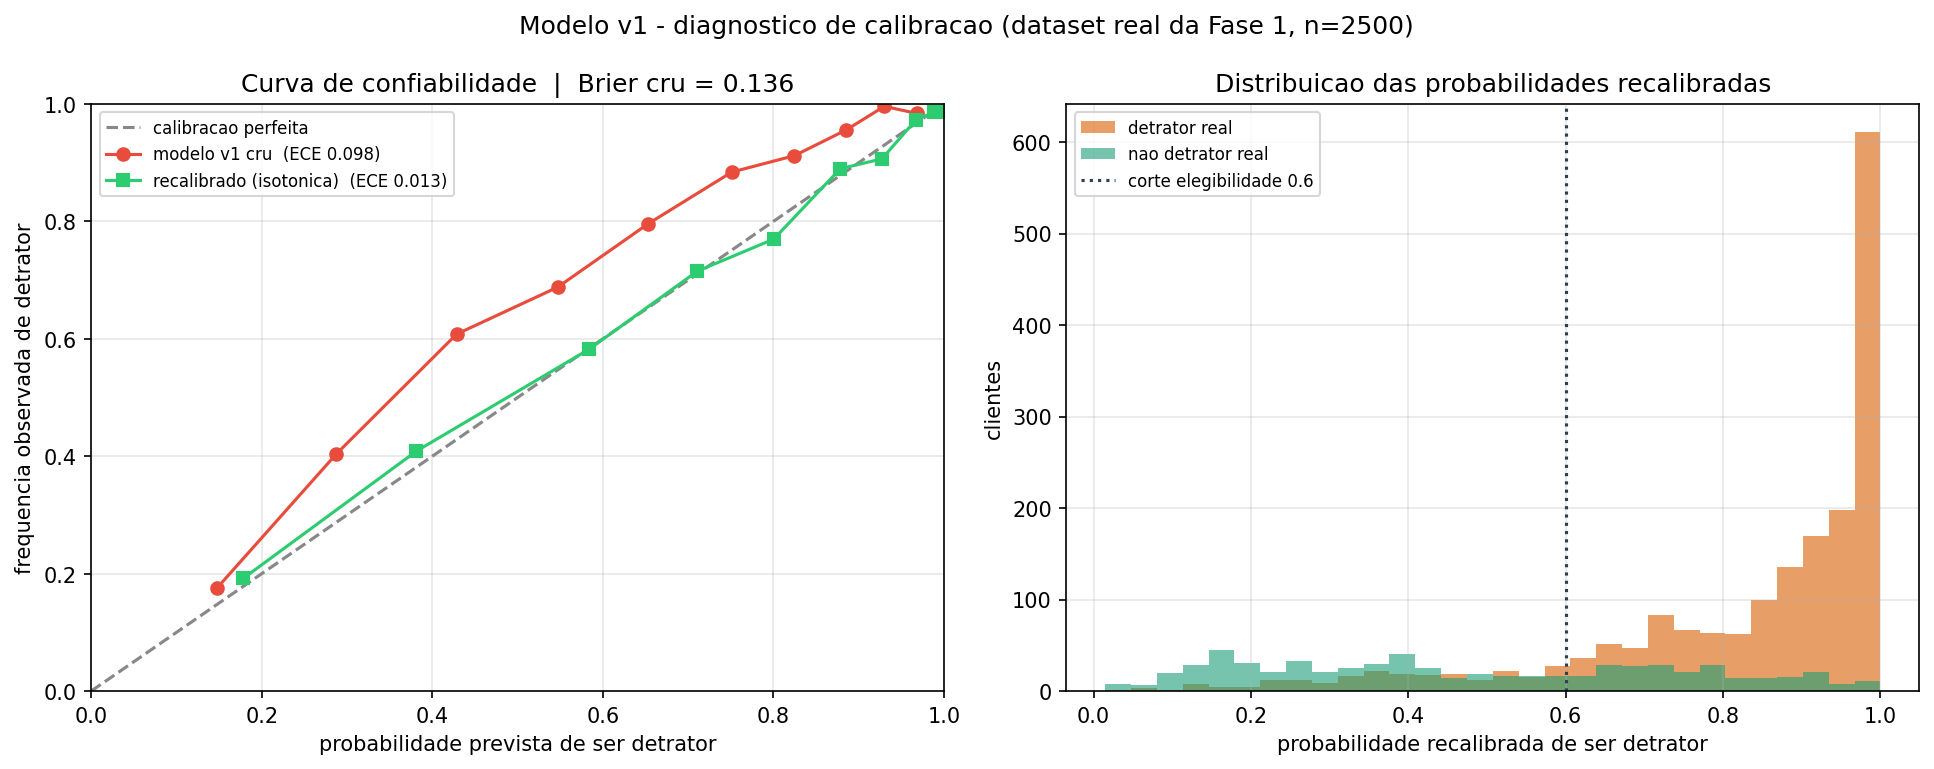

In [2]:
d = diagnosticar(salvar=True, verbose=False)
print(f"ECE cru: {d['ece']:.3f}  |  MCE: {d['mce']:.3f}")
print(f"ECE por CV externa: cru {d['ece_cru_cv_externa']:.3f} -> scorer recalibrado {d['ece_scorer_recalibrado_cv_externa']:.3f}")
print(f"veredito: {d['veredito']['acao']}")
Image(str(R / 'reliability_v1.png'))

A curva de confiabilidade fica **inteira acima da diagonal**: o modelo subestima risco em toda a faixa. Recalibração isotônica (`CalibratedClassifierCV`) derruba o ECE de ~0,10 para ~0,01. O experimento usa o **scorer recalibrado** (`models/v1/risco_detrator.pkl`).

### A seletividade do modelo é modesta — e isso é um achado

Quando há falha de entrega, a maioria dos clientes vira detrator de fato. O valor do modelo aqui é o **ranking de risco** para estratificar, não um gate sim/não afiado.

In [3]:
e = resumo_elegibilidade()
print(f"corte P >= {e['corte']}  ->  {e['n_elegivel']} clientes ({e['pct_da_base']:.0%} da base), ~{e['elegivel_por_mes']}/mês, densidade de detrator {e['densidade_detrator']:.1%}")
pd.DataFrame(e['estratos'])

corte P >= 0.6  ->  1806 clientes (72% da base), ~1806/mês, densidade de detrator 93.1%


,faixa,n,densidade_detrator
0,"[0.6, 0.75]",305,0.7213
1,"[0.75, 0.9]",458,0.9192
2,"[0.9, 1.01]",1043,0.9981


## 2. O gerador sintético (DGP)

Cada cliente elegível sintético reamostra um cliente real da Fase 1 (estrato e rótulo de detrator preservados). Para cada um sorteamos os **desfechos potenciais** de recompra em 90 dias: `y0` (sem ação) e `y1` (com ação), com um uniforme latente compartilhado que garante `y1 >= y0` (o cupom nunca piora).

O efeito plantado é **heterogêneo**: move mais o detrator recuperável (estrato 0) e quase nada o detrator quase certo (estrato 2).

In [4]:
pop = gerar_populacao(CenarioDGP(efeito='heterogeneo'))
resumo(pop)[['estrato','faixa','n','densidade_detrator','recompra_y0','recompra_y1','efeito_verdadeiro']]

,estrato,faixa,n,densidade_detrator,recompra_y0,recompra_y1,efeito_verdadeiro
0,0,"[0.6, 0.75)",1873,0.736786,0.182595,0.279231,0.091046
1,1,"[0.75, 0.9)",2674,0.915856,0.115183,0.159686,0.046634
2,2,"[0.9, 1.01)",6289,0.998410,0.058992,0.071076,0.011997


## 3. Sorteio estratificado e balanço

Sorteio ~75% tratamento / ~25% controle **dentro de cada estrato**. Um balde ralo (abaixo de 30 por braço) seria fundido com o vizinho por uma regra fixada a priori (PAVC). O sorteio aleatório garante que os braços são idênticos na média, exceto pela ação.

In [5]:
srt = sortear(pop)
checar_balanco(srt)

,covariavel,media_tratamento,media_controle,dif_padronizada
0,risco_calibrado,0.889678,0.889518,0.001408
1,detrator,0.929995,0.941285,-0.046015
2,delivery_delay_days,2.654035,2.648449,0.004063
3,customer_tenure_months,61.090428,61.000369,0.002588


## 4. A análise recupera o efeito plantado

O efeito causal por estrato = **taxa de recompra do tratamento menos a do controle**, com IC 95%. A prova de que o estimador é correto vem de rodar 80 réplicas com sementes diferentes: viés ~0 e cobertura do IC 95% ~0,95.

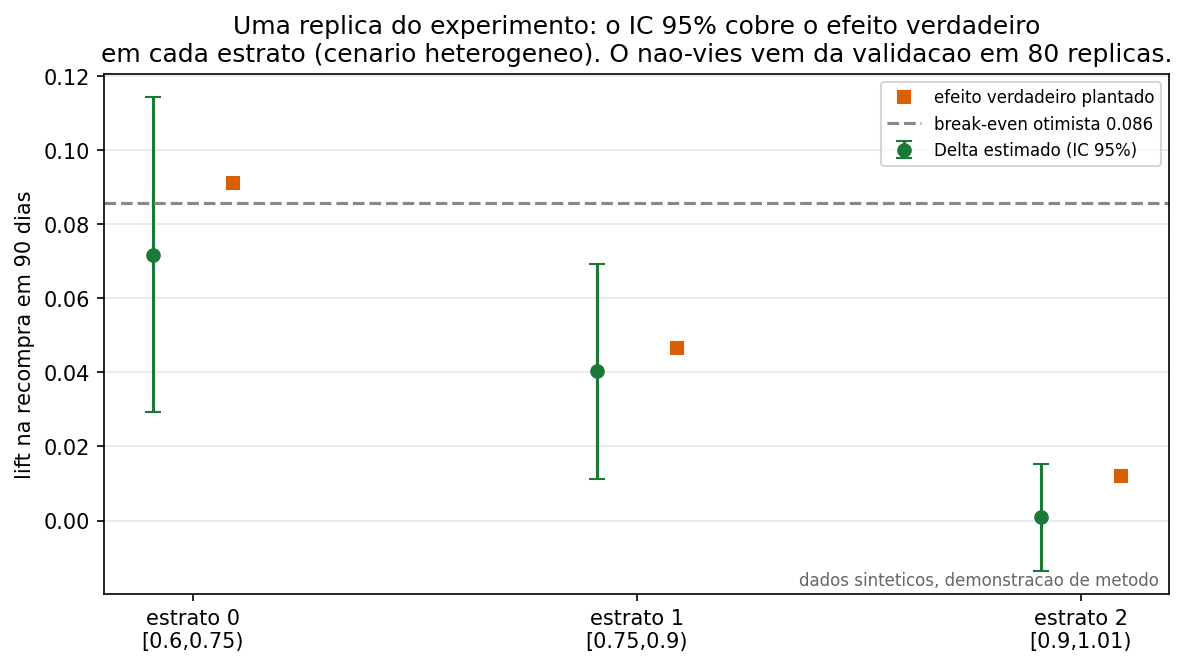

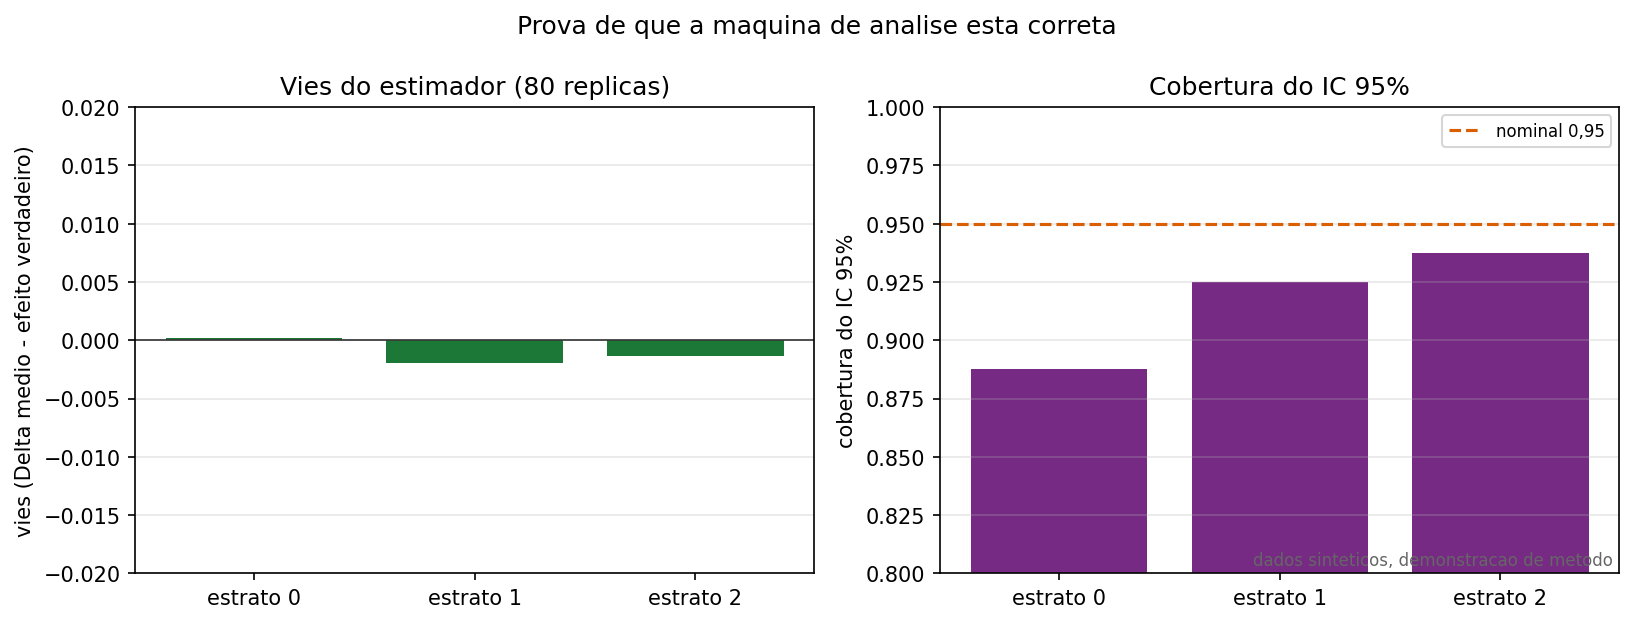

,estrato,delta_medio,efeito_verdadeiro,vies,cobertura_ic95,n_replicas
0,0,0.087043,0.089158,-0.002115,0.916667,60
1,1,0.044911,0.046755,-0.001844,0.933333,60
2,2,0.010764,0.011996,-0.001232,0.950000,60


In [6]:
display(Image(str(R / 'efeito_por_estrato.png')))
display(Image(str(R / 'validacao_estimador.png')))
validar_recuperacao(CenarioDGP(efeito='heterogeneo'), n_rep=60)

## 5. A decisão econômica depende do valor do cliente retido

`margem incremental por tratado = Delta x valor_cliente_retido - R$ 30`.

O `Delta` tem IC do experimento. O `valor_cliente_retido` é **`[revalidar]`** — entre R$ 105 (margem de contribuição) e R$ 350 (LTV bruto), sem distribuição conhecida. A regra pré-registrada propaga as **duas** incertezas por Monte Carlo (IC conjunto). Plantar o valor no ponto médio daria um IC falsamente estreito — exatamente a decisão sobre premissa não medida que o ADR-0002 combate.

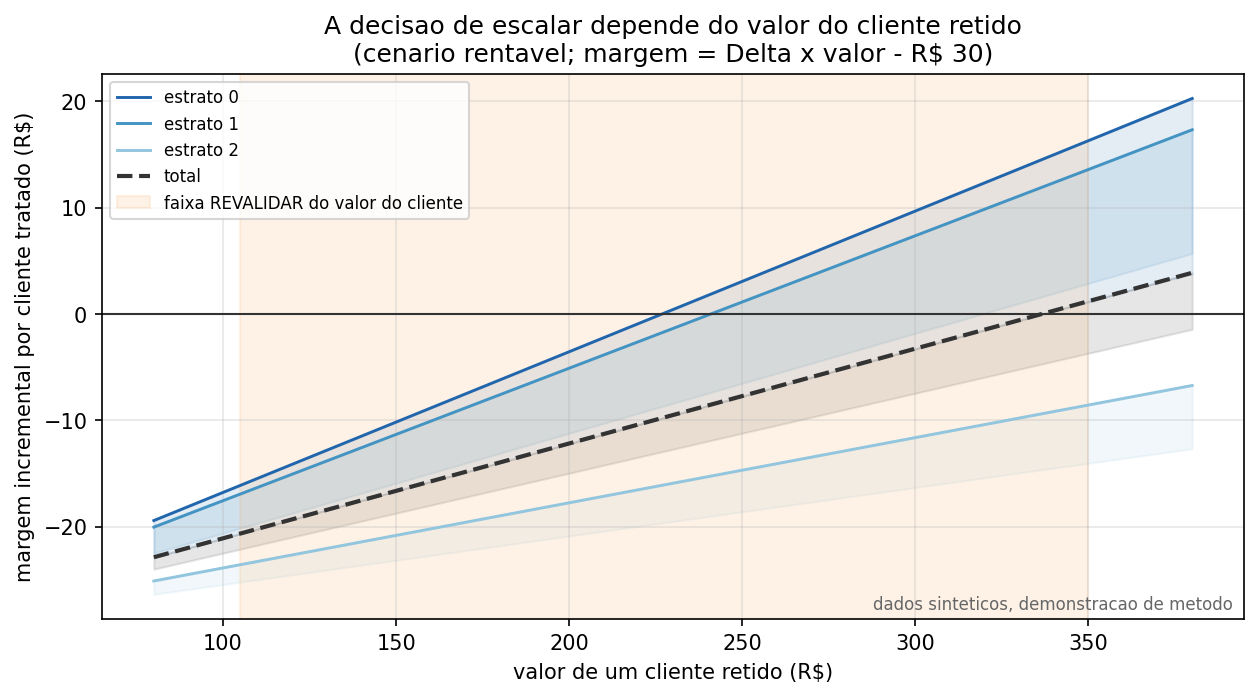


--- cenário 'nulo' ---
  estrato 0  Delta=-0.0129 (verdadeiro +0.0000)  P(margem>0)=0.00  -> nao escalar
  estrato 1  Delta=-0.0001 (verdadeiro +0.0000)  P(margem>0)=0.00  -> nao escalar
  estrato 2  Delta=-0.0113 (verdadeiro +0.0000)  P(margem>0)=0.00  -> nao escalar
  total      Delta=-0.0088 (verdadeiro +0.0000)  P(margem>0)=0.00  -> nao escalar

--- cenário 'heterogeneo' ---
  estrato 0  Delta=+0.0717 (verdadeiro +0.0910)  P(margem>0)=0.04  -> zona morta / depende do valor do cliente
  estrato 1  Delta=+0.0403 (verdadeiro +0.0466)  P(margem>0)=0.00  -> zona morta / depende do valor do cliente
  estrato 2  Delta=+0.0008 (verdadeiro +0.0120)  P(margem>0)=0.00  -> nao escalar
  total      Delta=+0.0228 (verdadeiro +0.0342)  P(margem>0)=0.00  -> zona morta / depende do valor do cliente

--- cenário 'rentavel' ---
  estrato 0  Delta=+0.1322 (verdadeiro +0.1500)  P(margem>0)=0.48  -> zona morta / depende do valor do cliente
  estrato 1  Delta=+0.1245 (verdadeiro +0.1291)  P(margem>0)=0.

In [7]:
display(Image(str(R / 'decisao_superficie.png')))
r = json.load(open(R / 'resultados.json', encoding='utf-8'))
for chave in ('nulo','heterogeneo','rentavel','forte'):
    print(f"\n--- cenário '{chave}' ---")
    for x in r['cenarios'][chave]['resultados']:
        print(f"  {x['alvo']:<10} Delta={x['delta']:+.4f} (verdadeiro {x['delta_verdadeiro']:+.4f})  P(margem>0)={x['prob_margem_positiva']:.2f}  -> {x['veredito']}")

Leitura: no cenário de efeito **nulo** a regra diz "não escalar" com folga. Nos cenários com efeito real, quase tudo cai em **"zona morta / depende do valor do cliente"** — porque se um cliente retido vale R$ 105, quase nenhum lift de recompra paga R$ 30 de cupom. O experimento mede o efeito com precisão; a decisão de escalar fica **bloqueada num número de CRM que ninguém mediu**. Esse é o ponto do ADR-0002.

## 6. Cenários PAVC: o que quebra se a mitigação não for aplicada

In [8]:
Markdown((R / 'pavc_cenarios.md').read_text(encoding='utf-8'))

# Cenarios PAVC - efeito no veredito

> dados sinteticos, demonstracao de metodo

Cenario base: efeito verdadeiro 'forte'. Cada linha mostra o que acontece quando uma mitigacao do PAVC NAO e aplicada.

| cenario | delta_total | delta_verdadeiro | prob_margem_positiva | veredito |
| --- | --- | --- | --- | --- |
| com todas as mitigacoes (desenho do spec) | 0.1401 | 0.1509 | 0.5550 | zona morta / depende do valor do cliente |
| contaminacao do controle 30% ignorada | 0.0950 | 0.1509 | 0.1400 | zona morta / depende do valor do cliente |
| janela ancorada na acao, nao na entrega | 0.1334 | 0.1509 | 0.5100 | zona morta / depende do valor do cliente |


Contaminação de 30% do controle (alguém de CX liga e resolve o problema por fora) puxa o `Delta` medido para baixo em quase um terço — viés **para o nulo**, que empurra para o Erro A (matar um programa que funcionava). Por isso a taxa de contaminação é guardrail, e acima de ~10% a análise passa a exigir estimador de efeito no cumpridor (CACE).

## 7. Quantos clientes, quanto tempo

`n` por braço para um teste de duas proporções (alocação 75/25). A duração é `n / elegíveis por mês`. O teto pré-registrado é de 6 meses.

,alvo,mde,escopo,n_total,duracao_meses,cabe_no_teto_6m
0,break-even otimista (LTV R$350),0.086,total,916,0.51,True
1,break-even otimista (LTV R$350),0.086,0,916,3.00,True
2,"intermediario (+0,05)",0.050,total,2432,1.35,True
3,"intermediario (+0,05)",0.050,0,2432,7.97,False
4,break-even conservador (margem R$105),0.286,total,116,0.06,True
5,break-even conservador (margem R$105),0.286,0,116,0.38,True


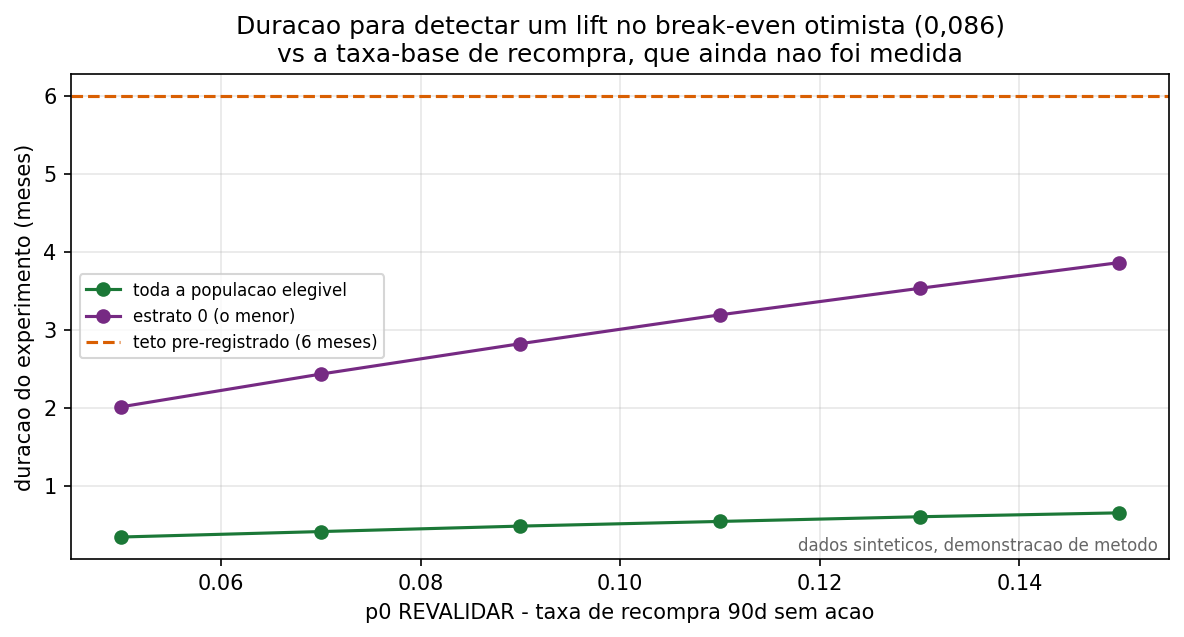

In [9]:
display(tabela_mde(p0=0.10))
Image(str(R / 'sensibilidade_p0.png'))

Detectar um lift no **break-even otimista (0,086)** cabe em ~3 meses no estrato menor. Detectar um lift **intermediário (0,05)** estoura o teto de 6 meses no estrato 0 (7,8 meses). É a falha 2 do PAVC quantificada: se o efeito real for modesto, o experimento não converge no prazo, e o veredito passa a ser *"efeito pequeno demais para pagar no volume atual — não escala"*.

In [10]:
criterio_pre_registrado()

{'desfecho_primario': 'recompra em 90 dias, em margem incremental por cliente tratado',
 'regra_de_escala': 'escalar so se o limite inferior do IC 95% CONJUNTO (efeito x valor_cliente_retido) da margem por tratado for > 0',
 'zona_morta': 'IC conjunto contem zero mas mediana positiva -> nao escala, reformula',
 'teto_duracao_meses': 6,
 'veredito_no_teto': 'se ao fim de 6 meses o IC ainda cruza o break-even: efeito pequeno demais para pagar no volume atual -> nao escala',
 'guardrails': ['taxa de detrator entre respondentes nao piora no tratado',
  'reclamacoes e contatos de SAC nao sobem no tratado'],
 'revalidar_antes_de_executar': ['p0 de recompra 90d sem acao (piloto ou CRM)',
  'valor_cliente_retido (margem de contribuicao, nao LTV de brochura)']}

## O que este notebook NÃO afirma

- que o cupom funciona ou gera ROI — o efeito foi escolhido no gerador;
- qualquer número de efeito ou ROI como resultado real;
- que a taxa-base de recompra ou o valor do cliente retido são os usados aqui — são premissas declaradas, marcadas `[revalidar]`.

O que ele demonstra é **competência de método**: desenhar um A/B que isola o efeito da ação, recuperar esse efeito com o IC certo, propagar a incerteza do valor do cliente na decisão e dimensionar o experimento contra um teto de calendário.